In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings

warnings.filterwarnings("ignore")

titanic_url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

titanic_df = pd.read_csv(titanic_url)

titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [20]:
titanic_df['Age'].fillna(titanic_df['Age'].median(), inplace=True)
titanic_df['Embarked'].fillna(titanic_df['Embarked'].mode()[0], inplace=True)
titanic_df['Fare'].fillna(titanic_df['Fare'].median(), inplace=True)

titanic_df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)

encoder = LabelEncoder()

titanic_df['Sex'] = encoder.fit_transform(titanic_df['Sex'])
titanic_df['Embarked'] = encoder.fit_transform(titanic_df['Embarked'])

X_titanic = titanic_df.drop('Survived', axis=1)
y_titanic = titanic_df['Survived']

scaler_titanic = StandardScaler()

X_titanic_scaled = scaler_titanic.fit_transform(X_titanic)

X_train, X_test, y_train, y_test = train_test_split(
    X_titanic_scaled,
    y_titanic,
    test_size=0.20,
    stratify=y_titanic,
    random_state=42
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (712, 7)
Test set shape: (179, 7)


In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr_model = LogisticRegression(random_state=42)

lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_preds)

print(f"Logistic Regression Test Accuracy: {lr_accuracy * 100:.2f}%")

Logistic Regression Test Accuracy: 79.89%


In [21]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda_model = LinearDiscriminantAnalysis()

lda_model.fit(X_train, y_train)

lda_preds = lda_model.predict(X_test)

lda_accuracy = accuracy_score(y_test, lda_preds)

print(f"LDA Test Accuracy: {lda_accuracy*100:.2f}%")

LDA Test Accuracy: 79.33%


In [6]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

knn_accuracy = accuracy_score(y_test, y_pred_knn)

print(f"k-NN Classification Accuracy: {knn_accuracy * 100:.2f}%")

k-NN Classification Accuracy: 81.56%


In [7]:
comparison_df = pd.DataFrame({
    'Supervised Classifier': [
        'Logistic Regression',
        'Linear Discriminant Analysis (LDA)',
        'k-Nearest Neighbors (k-NN)'
    ],
    'Test Accuracy (%)': [
        lr_accuracy * 100,
        lda_accuracy * 100,
        knn_accuracy * 100
    ]
})

print("--- Performance Comparison on Titanic Dataset ---")

print(comparison_df.to_string(index=False))

--- Performance Comparison on Titanic Dataset ---
             Supervised Classifier  Test Accuracy (%)
               Logistic Regression          79.888268
Linear Discriminant Analysis (LDA)          79.329609
        k-Nearest Neighbors (k-NN)          81.564246


In [8]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

nb_model = GaussianNB()

nb_model.fit(X_train, y_train)

nb_preds = nb_model.predict(X_test)

nb_accuracy = accuracy_score(y_test, nb_preds)

print(f"Gaussian Naïve Bayes Test Accuracy: {nb_accuracy * 100:.2f}%")

Gaussian Naïve Bayes Test Accuracy: 78.21%


In [9]:
from sklearn.svm import SVC

svm_linear = SVC(kernel='linear', probability=True, random_state=42)

svm_linear.fit(X_train, y_train)

linear_preds = svm_linear.predict(X_test)

linear_accuracy = accuracy_score(y_test, linear_preds)

print(f"Linear Kernel SVM Test Accuracy: {linear_accuracy * 100:.2f}%")

Linear Kernel SVM Test Accuracy: 77.65%


In [10]:
sonar_comparison = pd.DataFrame({

    'Classifier': [

        'Gaussian Naïve Bayes',

        'Linear Kernel SVM'

    ],

    'Test Accuracy (%)': [

        nb_accuracy * 100,

        linear_accuracy * 100

    ]

})

print("--- Performance Comparison on Titanic Dataset ---")

print(sonar_comparison.to_string(index=False))

--- Performance Comparison on Titanic Dataset ---
          Classifier  Test Accuracy (%)
Gaussian Naïve Bayes          78.212291
   Linear Kernel SVM          77.653631


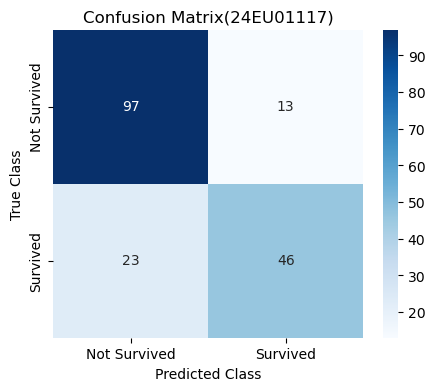

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, lr_preds)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Survived','Survived'],
    yticklabels=['Not Survived','Survived']
)

plt.title("Confusion Matrix(24EU01117)")
plt.ylabel("True Class")
plt.xlabel("Predicted Class")
plt.show()

In [12]:
from sklearn.metrics import classification_report

report_output = classification_report(
    y_test,
    lr_preds,
    target_names=['Not Survived','Survived']
)

print("--- Logistic Regression Classification Report ---")

print(report_output)

--- Logistic Regression Classification Report ---
              precision    recall  f1-score   support

Not Survived       0.81      0.88      0.84       110
    Survived       0.78      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.79      0.77      0.78       179
weighted avg       0.80      0.80      0.80       179



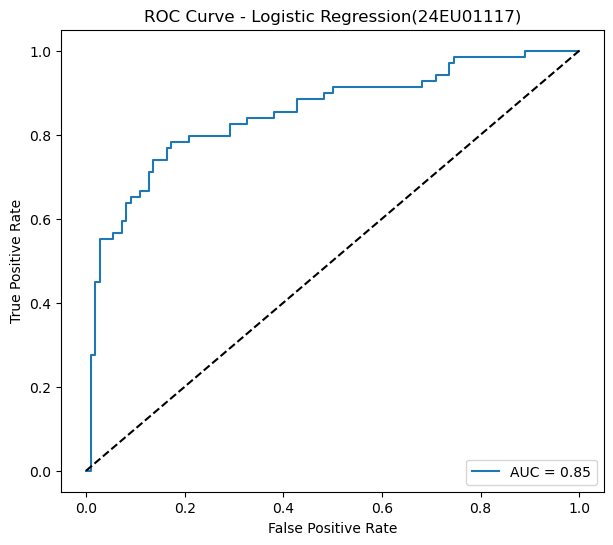

In [13]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_score = lr_model.predict_proba(X_test)

fpr, tpr, thresholds = roc_curve(y_test, y_score[:,1])

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))

plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Logistic Regression(24EU01117)")

plt.legend(loc="lower right")

plt.show()

In [14]:
from sklearn.model_selection import cross_val_score
import numpy as np

cv_scores = cross_val_score(
    lr_model,
    X_titanic_scaled,
    y_titanic,
    cv=5,
    scoring='accuracy'
)

print("5-Fold Cross-Validation Accuracy:")

for i, score in enumerate(cv_scores, start=1):
    print(f"Fold {i}: {score:.4f}")

print("\nMean Accuracy: {:.2f}%".format(np.mean(cv_scores) * 100))
print("Standard Deviation: {:.2f}%".format(np.std(cv_scores) * 100))

5-Fold Cross-Validation Accuracy:
Fold 1: 0.7709
Fold 2: 0.7865
Fold 3: 0.7809
Fold 4: 0.7640
Fold 5: 0.8202

Mean Accuracy: 78.45%
Standard Deviation: 1.95%
